Importação de Bibliotecas

In [183]:
import plotly.express as px
import pandas as pd
import seaborn as sns
import re
from matplotlib import pyplot as plt

Atribuição de DataFrames

In [184]:
df_data = pd.read_csv('rest_data_us_upd.csv', dtype={'object_type': 'category'})

Pré-Análise do DataFrame

In [185]:
df_data.info()
df_data.describe()
print(df_data.sample(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9651 non-null   int64   
 1   object_name  9651 non-null   object  
 2   address      9651 non-null   object  
 3   chain        9648 non-null   object  
 4   object_type  9651 non-null   category
 5   number       9651 non-null   int64   
dtypes: category(1), int64(2), object(3)
memory usage: 386.8+ KB
         id        object_name                    address  chain object_type  \
1433  13219     BLVD HOTEL BAR        2010 N HIGHLAND AVE  False         Bar   
1370  13156         DONUT TOWN  10306 S WILMINGTON AVE #B  False   Fast Food   
7031  18817            ANZUTEI            633 S SPRING ST  False  Restaurant   
7693  19479      MAGEE'S DONUT         1290 S LA BREA AVE  False   Fast Food   
259   12045     SPRING ST. BAR      626 S SPRING ST STE B  False         Bar   
7383 

In [186]:
df_data['object_type'].nunique()
df_data['object_type'].unique()
df_data['object_type'].value_counts()

object_type
Restaurant    7255
Fast Food     1066
Cafe           435
Pizza          320
Bar            292
Bakery         283
Name: count, dtype: int64

In [187]:
df_data = df_data.dropna(subset=['chain'])
df_data['chain'].unique()

array([False, True], dtype=object)

In [188]:
df_data['chain'] = df_data['chain'].astype(bool)

In [189]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9648 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   id           9648 non-null   int64   
 1   object_name  9648 non-null   object  
 2   address      9648 non-null   object  
 3   chain        9648 non-null   bool    
 4   object_type  9648 non-null   category
 5   number       9648 non-null   int64   
dtypes: bool(1), category(1), int64(2), object(2)
memory usage: 395.9+ KB


In [190]:
df_data.duplicated().sum()

np.int64(0)

Passo 2. Análise de dados

Investigue as proporções de vários tipos de estabelecimentos. Construa um gráfico.

In [191]:
data_proportion_store = df_data['object_type'].value_counts().reset_index()
print(data_proportion_store)

  object_type  count
0  Restaurant   7253
1   Fast Food   1066
2        Cafe    435
3       Pizza    319
4         Bar    292
5      Bakery    283


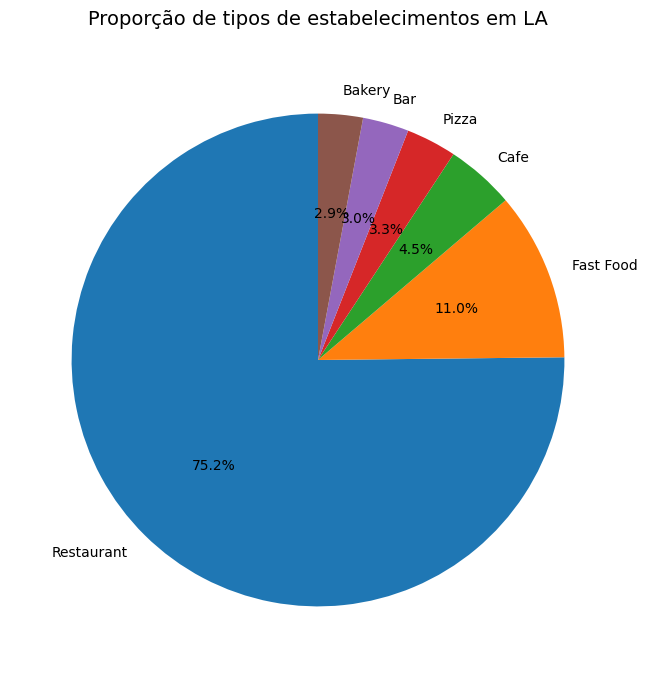

In [192]:
plt.figure(figsize=(12, 8))
plt.pie(data_proportion_store['count'], labels=data_proportion_store['object_type'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de tipos de estabelecimentos em LA', fontsize=14, pad=20)
plt.show()

A partir dos dados de proporção de tipos de estabelecimentos na cidade de Los Angeles, dá pra ver que 75% do mercado é dominado por restaurantes, em segundo lugar estando os fast food com 11% do mercado, enquanto outros tipos de estabelecimento aparecem com baixa presença no mercado, como por exemplo cafeterias com 4,5%. Isso pode indicar tanto uma oportunidade de mercado pouco explorado quanto uma menor demanda por esses tipos de estabelecimento na região.

Investigue as proporções de estabelecimentos de rede e não. Construa um gráfico.

In [193]:
data_proportion_franchise = df_data['chain'].value_counts().reset_index()
print(data_proportion_franchise)

   chain  count
0  False   5972
1   True   3676


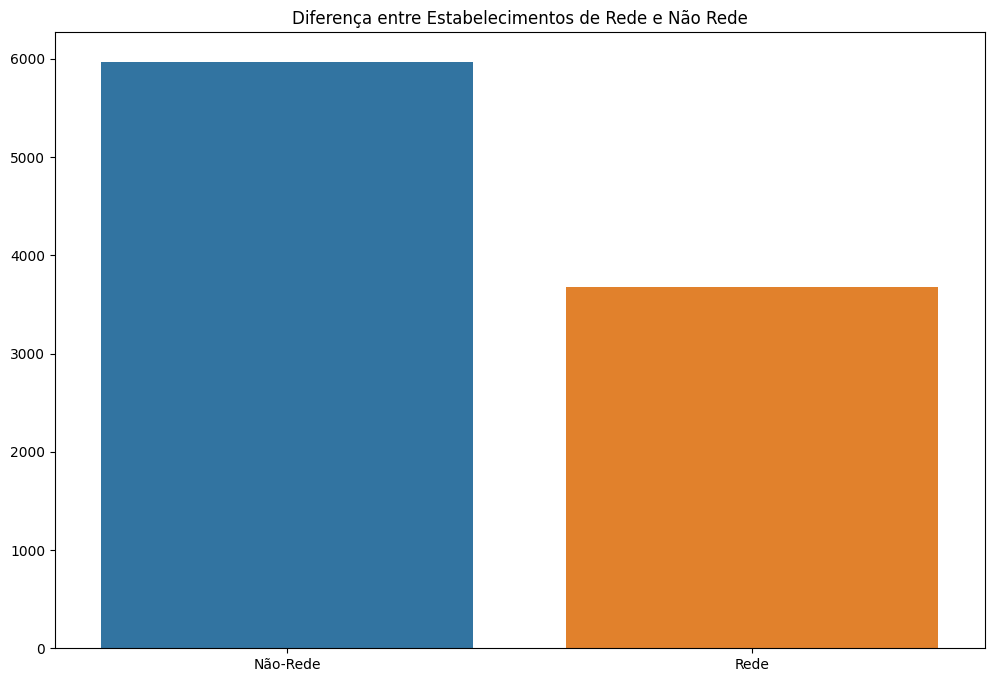

In [194]:
data_proportion_franchise['chain'] = data_proportion_franchise['chain'].map({True: 'Rede', False: 'Não-Rede'})
plt.figure(figsize=(12,8))
sns.barplot(data= data_proportion_franchise, x='chain', y='count', hue='chain')
plt.xlabel('')
plt.ylabel('')
plt.title('Diferença entre Estabelecimentos de Rede e Não Rede')
plt.show()


Aqui vemos que a maioria dos estabelecimentos de Los Angeles não faz parte de uma rede comercial, representando cerca de 60% do mercado os sem filiação

Qual tipo de estabelecimento é típico para redes?

In [195]:
data_franchise_store = df_data[df_data['chain'] == True]['object_type'].value_counts().reset_index()
print(data_franchise_store)

  object_type  count
0  Restaurant   2292
1   Fast Food    605
2      Bakery    283
3        Cafe    266
4       Pizza    153
5         Bar     77


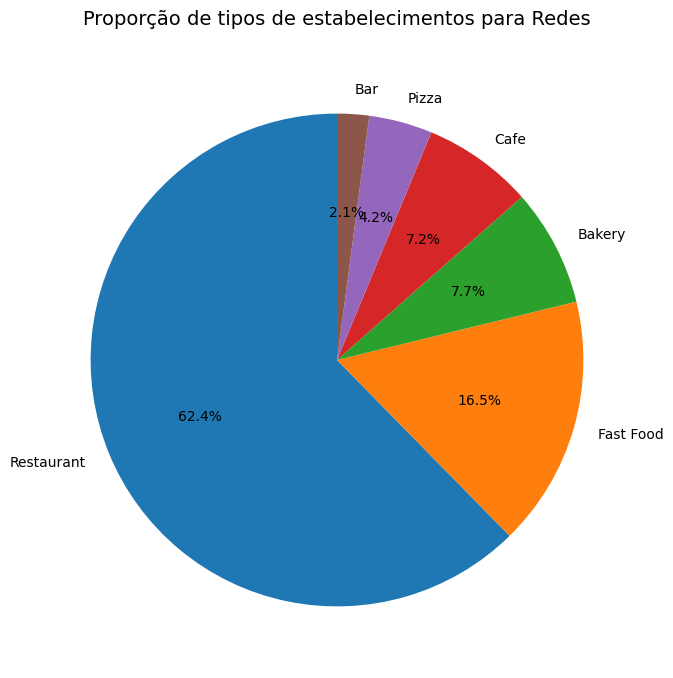

In [196]:
plt.figure(figsize=(12, 8))
plt.pie(data_franchise_store['count'], labels=data_franchise_store['object_type'], autopct='%1.1f%%', startangle=90)
plt.title('Proporção de tipos de estabelecimentos para Redes', fontsize=14, pad=20)
plt.show()

Como visto no primeiro gráfico, restaurantes dominam o mercado geral com 75%, mas entre as redes essa proporção cai para 62%. Em contrapartida, o Fast Food sobe de 11% para 16.5% nas redes, o que faz sentido dado que esse tipo de estabelecimento tem um modelo de negócio mais padronizado e fácil de escalar. Bakery também chama atenção — representa apenas 2.9% do mercado geral mas 7.7% das redes, sugerindo que padarias têm uma tendência maior à franquia.

O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

In [197]:
data_chairs_count = df_data.groupby('object_type')['number'].sum()
print(data_chairs_count)

object_type
Bakery          6162
Bar            13072
Cafe           10875
Fast Food      33939
Pizza           9106
Restaurant    348498
Name: number, dtype: int64


C:\Users\GAMER\AppData\Local\Temp\ipykernel_18520\4257056875.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_chairs_count = df_data.groupby('object_type')['number'].sum()


In [198]:
df_data.groupby('chain')['number'].mean()

chain
False    46.171467
True     39.694233
Name: number, dtype: float64

In [199]:
df_data[df_data['chain'] == True].groupby('object_name')['id'].count().sort_values(ascending=False).head(10)

object_name
THE COFFEE BEAN & TEA LEAF    47
SUBWAY                        31
DOMINO'S PIZZA                15
KENTUCKY FRIED CHICKEN        14
WABA GRILL                    14
MCDONALD'S                    13
TRIMANA                       13
STARBUCKS                     12
PAPA JOHN'S PIZZA             12
HONG KONG EXPRESS             12
Name: id, dtype: int64

De acordo com os dados extraídos, redes se caracterizam por terem mais estabelecimentos e menos cadeiras, o que favorece as crenças de que redes priorizam a rotatividade maior de clientes dentro dos estabelecimentos

Determine o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos? Construa gráficos.

In [200]:
data_chairs_object_type = df_data.groupby('object_type')['number'].mean().reset_index()
print(data_chairs_object_type)

  object_type     number
0      Bakery  21.773852
1         Bar  44.767123
2        Cafe  25.000000
3   Fast Food  31.837711
4       Pizza  28.545455
5  Restaurant  48.048807


C:\Users\GAMER\AppData\Local\Temp\ipykernel_18520\4199050570.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_chairs_object_type = df_data.groupby('object_type')['number'].mean().reset_index()


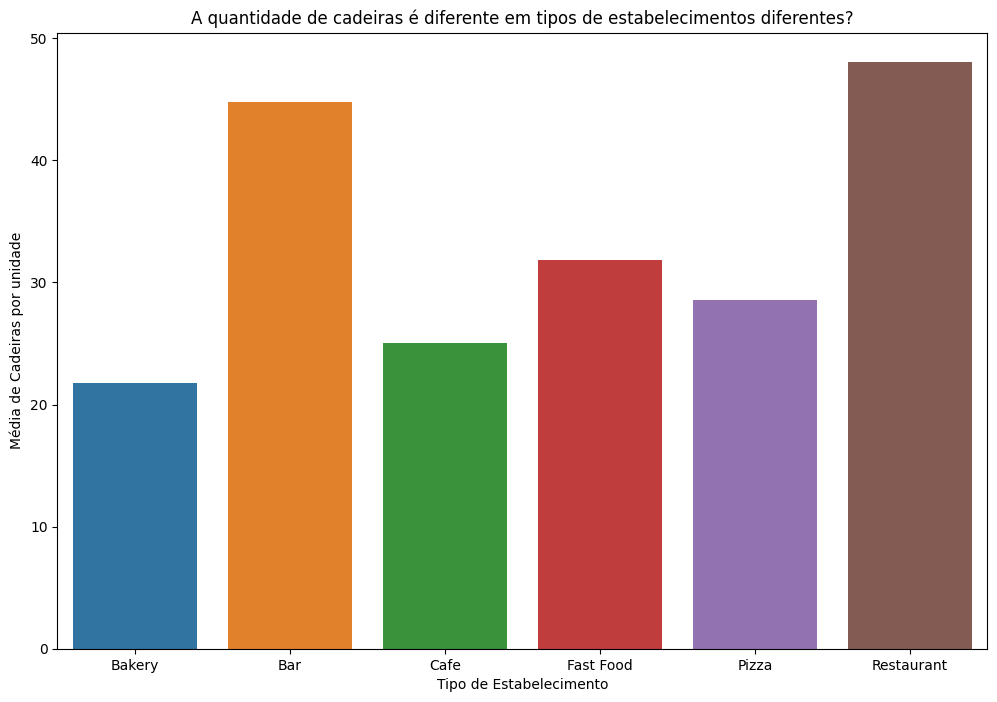

In [201]:
plt.figure(figsize=(12,8))
sns.barplot(data= data_chairs_object_type, x='object_type', y='number', hue='object_type')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Média de Cadeiras por unidade')
plt.title('A quantidade de cadeiras é diferente em tipos de estabelecimentos diferentes?')
plt.show()


Estabelecimentos focados atender o cliente por um tempo maior, como um Restaurante ou um Bar tendem a ter um número médio maior de cadeiras por estabelecimento(48 e 44) enquanto padarias que geralmente realizam o atendimento em um tempo mais rápido tem menos cadeiras(21)

Coloque os dados dos nomes das ruas da coluna address em uma coluna separada.

In [202]:
df_data['street'] = df_data['address'].str.replace(r'^\d+\s+\d+/\d+\s+', '', regex=True)
df_data['street'] = df_data['street'].str.replace(r'^\d+\s+', '', regex=True)
df_data['street'] = df_data['street'].str.replace(r'\s+(STE|#|UNIT|APT).*$', '', regex=True)

In [203]:
df_data['street'].isna().sum()

np.int64(0)

In [204]:
df_data[['address', 'street']].sample(10)

,address,street
330,6151 W CENTURY BLVD STE D,W CENTURY BLVD
8567,722 W FLORENCE AVE,W FLORENCE AVE
8095,706 N VERMONT AVE,N VERMONT AVE
9141,2815 W SUNSET BLVD,W SUNSET BLVD
7957,369 E 2ND ST,E 2ND ST
9641,2851 CRENSHAW BLVD,CRENSHAW BLVD
1803,3650 W MLK BLVD FC-10,W MLK BLVD FC-10
7473,3804 BROADWAY PL,BROADWAY PL
5565,11301 W OLYMPIC BLVD STE 105,W OLYMPIC BLVD
7819,2700 COLORADO BLVD STE #144,COLORADO BLVD


In [213]:
df_data_street_gb = df_data.groupby('street')['id'].count().sort_values(ascending=False).reset_index()
df_data_street_gb.columns = ['street', 'count']
df_data_street_gb_ten = df_data_street_gb.head(10)

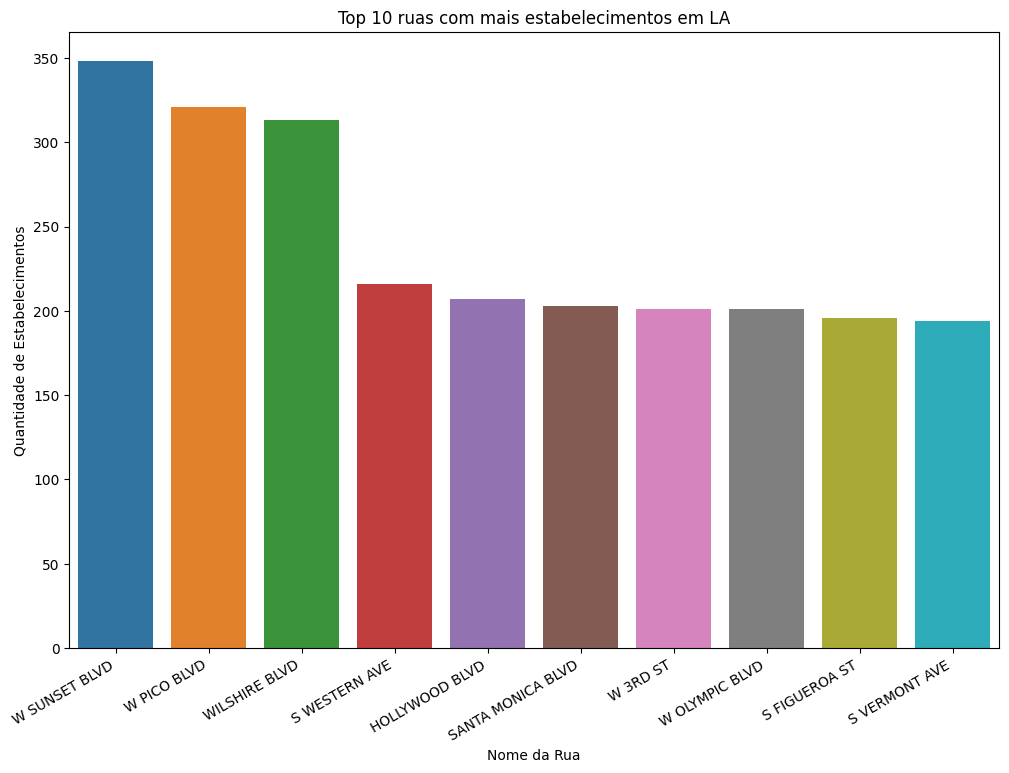

In [206]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_data_street_gb_ten, x='street', y='count', hue='street')
plt.xlabel('Nome da Rua')
plt.ylabel('Quantidade de Estabelecimentos')
plt.title('Top 10 ruas com mais estabelecimentos em LA')
plt.xticks(rotation=30, ha='right')
plt.show()

Com base nos dados extraídos conseguimos ver que há 3 ruas que mesmo no top10 se destacam das outras em quantidade de restaurantes, sendo a W Sunset BLVD, W Pico BLVD e a Wilshire BLVD, todas tendo mais de 300 restaurantes em cada, enquanto a partir da quarta S Western AVE há pouco mais de 200

Encontre o número de ruas que têm apenas um restaurante.

In [207]:
df_data_single = len(df_data_street_gb[df_data_street_gb['count'] == 1])
df_data_street_count = len(df_data_street_gb)
print(f'Existem {df_data_street_count} ruas em LA com restaurantes, destas {df_data_single} têm apenas um restaurante')

Existem 1659 ruas em LA com restaurantes, destas 1156 têm apenas um restaurante


Para as ruas com muitos restaurantes, olhe para a distribuição de número de assentos. Quais tendências você consegue notar?

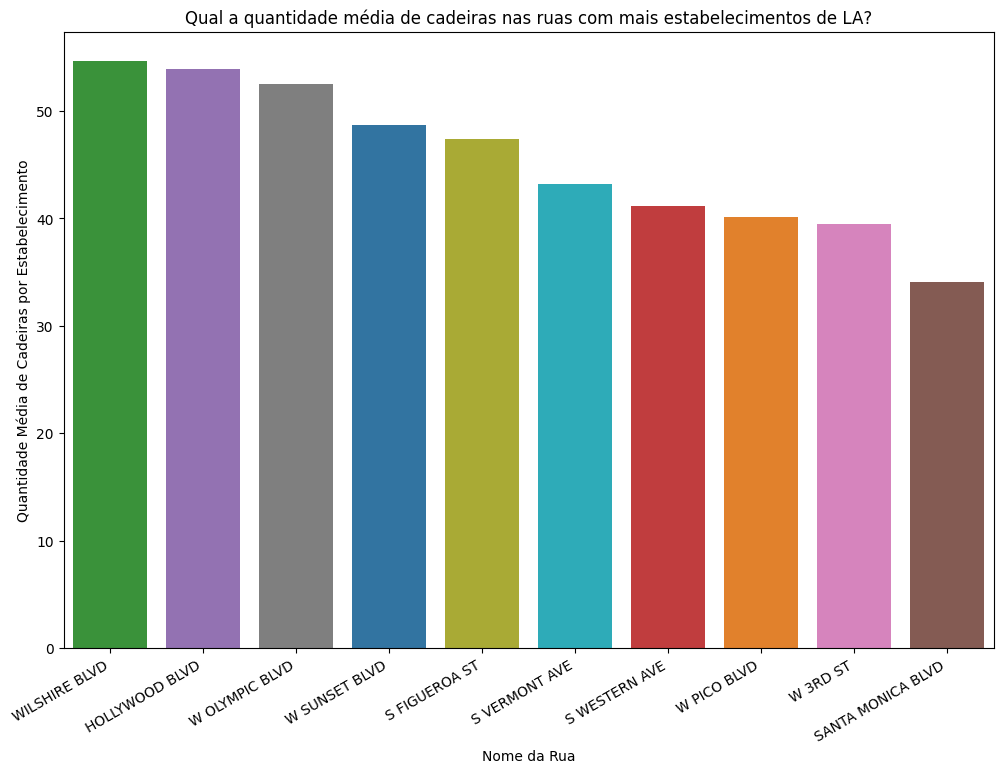

In [230]:
df_data_ten_number = df_data.groupby('street')[['id', 'number']].agg({'id': 'count', 'number': 'mean'}).sort_values(by= 'id', ascending=False).reset_index().head(10)
order = df_data_ten_number.sort_values('number', ascending=False)['street']
df_data_ten_number

plt.figure(figsize=(12, 8))
sns.barplot(data= df_data_ten_number, x='street', y='number', hue='street', order=order)
plt.xticks(rotation=30, ha='right')
plt.xlabel('Nome da Rua')
plt.ylabel('Quantidade Média de Cadeiras por Estabelecimento')
plt.title('Qual a quantidade média de cadeiras nas ruas com mais estabelecimentos de LA?')
plt.show()


CONCLUSÃO FINAL

Nosso cliente deseja abrir uma cafeteria automatizada por robôs em LA, depois da análise de vários fatores eu acredito que abrir uma cafeteria sem franquia em uma rua com poucos comercios pode ser uma boa estratégia, mais de metade das ruas de LA que tivemos para analisar tem somente um estabelecimento, e cafeteria é um ramo com baixa presença em LA, representando apenas 4,5% dos restaurantes totais, de acordo com os dados as cafeterias de LA tem em média 25 cadeiras, porém como pode se perceber no gráfico de cadeiras das ruas mais movimentadas, caso o cliente decida tentar abrir em uma rua mais concorrida ele vai precisar aumentar a quantidade total de cadeiras. Para o ponto de uma cafeteria de rede, 7,2% dos estabelecimentos de rede são cafeteria, sendo algo plausível para uma futura expansão, porém se tratando do estilo de negócio de atendentes robôs eu recomendo consolidar primeiro o negócio para depois expandir, baseado somente nesses dados eu não recomendo abrir uma franquia logo de inicio sem saber como vai ser a recepção do publico